In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import logging
logging.basicConfig(level=logging.INFO)

In [58]:
from pathlib import Path

from brain_image.model import EEGAlignmentModel

cp_path = Path("logs/nice/version_120/checkpoints/nice-epoch=02-VAL__loss=0.1317.ckpt")

import torch
from lightning import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint


device = "cuda"
dtype = torch.float32

model = EEGAlignmentModel.load_checkpoint(cp_path, undo_compile=True, preload_latents=False).to(device, dtype=dtype)

In [8]:
from brain_image.utils import investigate_tensor


model.eval()
model.set_mode("val")

tensor_cache = model.tensor_cache

val_dataloader = model.val_dataloader()
img_paths = []
all_eeg_datas_ = []
all_aligned_latents_ = []
all_high_clip_latents_ = []
all_used_high_clip_latents_ = []

for batch_idx , batch in enumerate(val_dataloader):
    prepped_batch = model.prepare_batch(batch, "val")
    img_paths.extend(batch["img_path"])
    all_eeg_datas_.extend(batch["eeg_data"])
    all_aligned_latents_.extend(model._get_batch_from_cache(batch["img_path"], "align", model.config.align_target_model, "test"))
    all_high_clip_latents_.extend(model._get_batch_from_cache(batch["img_path"], "recon", model.config.high_recon_model, "test"))
    all_used_high_clip_latents_.extend(batch["high_recon_image_latent"])

all_eeg_datas = torch.stack(all_eeg_datas_)
all_aligned_latents = torch.stack(all_aligned_latents_)
all_high_clip_latents = torch.stack(all_high_clip_latents_)
all_used_high_clip_latents = torch.stack(all_used_high_clip_latents_)

investigate_tensor("all_eeg_datas", all_eeg_datas)
investigate_tensor("all_aligned_latents", all_aligned_latents)
investigate_tensor("all_high_clip_latents", all_high_clip_latents)
investigate_tensor("all_used_high_clip_latents", all_used_high_clip_latents)

investigate_tensor("all_high_clip_latents (256)", all_high_clip_latents[:256])

Name: all_eeg_datas
* shape: (2000, 17, 100)
* dtype: torch.float32
* norm: 2.273
* min: -0.508
* max: 0.442
* mean: -0.054
* std: 0.214
Name: all_aligned_latents
* shape: (2000, 768)
* dtype: torch.float32
* norm: 14.730
* min: -8.001
* max: 2.099
* mean: -0.057
* std: 0.529
Name: all_high_clip_latents
* shape: (2000, 768)
* dtype: torch.float32
* norm: 18.775
* min: -7.973
* max: 8.561
* mean: 0.008
* std: 0.678
Name: all_used_high_clip_latents
* shape: (2000, 768)
* dtype: torch.float32
* norm: 18.775
* min: -7.973
* max: 8.561
* mean: 0.008
* std: 0.678
Name: all_high_clip_latents (256)
* shape: (256, 768)
* dtype: torch.float32
* norm: 18.762
* min: -7.956
* max: 8.543
* mean: 0.008
* std: 0.677


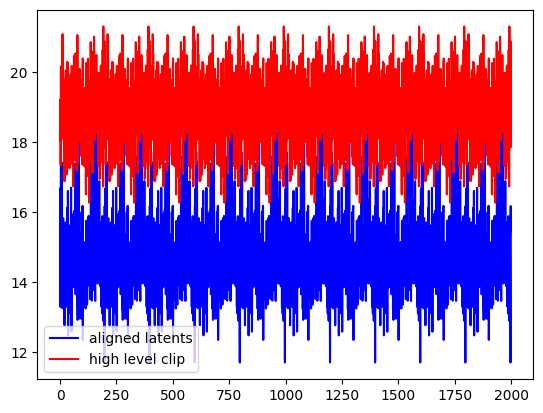

In [9]:
# Plot distribution of norms

import numpy as np
import matplotlib.pyplot as plt


aligned_latent_norms = all_aligned_latents.norm(p=2, dim=-1)
high_clip_norms = all_high_clip_latents.norm(p=2, dim=-1)

plt.plot(np.arange(aligned_latent_norms.shape[0]), aligned_latent_norms, c="blue", label="aligned latents")
plt.plot(np.arange(high_clip_norms.shape[0]), high_clip_norms, c="red", label="high level clip")
plt.legend()

# Alignment

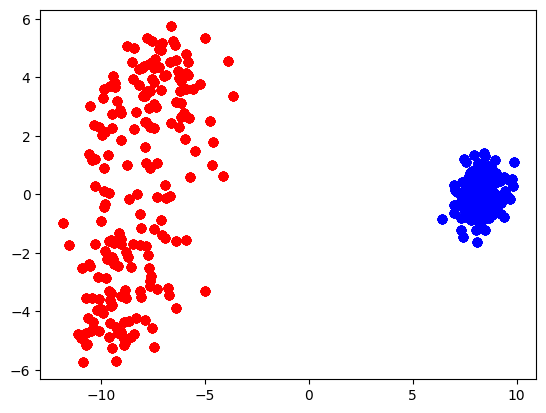

In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

n = len(all_aligned_latents)
joint_latents = torch.cat((all_aligned_latents, all_high_clip_latents), dim=0)

pca = PCA(2)
joint_latents_lowdim = pca.fit_transform(joint_latents)
plt.scatter(joint_latents_lowdim[:n, 0], all_aligned_latents[:n, 1], c="blue", label="aligned latents")
plt.scatter(joint_latents_lowdim[n:, 0], joint_latents_lowdim[n:, 1], c="red", label="high level clip")

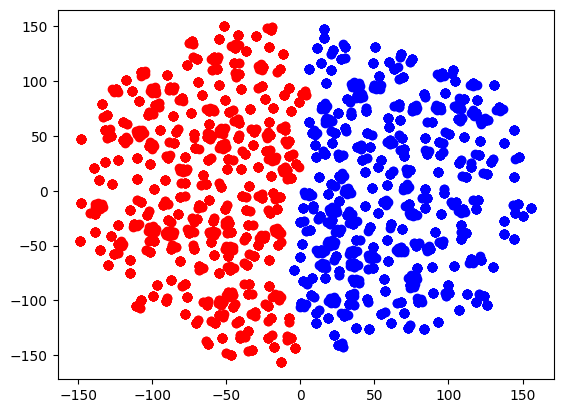

In [11]:
pca_hidden = PCA(50)
tsne = TSNE(2)

joint_latents_mid = pca_hidden.fit_transform(joint_latents)
joint_latents_low_tsne = tsne.fit_transform(joint_latents_mid)

plt.scatter(joint_latents_low_tsne[:n, 0], joint_latents_low_tsne[:n, 1], c="blue", label="aligned latents")
plt.scatter(joint_latents_low_tsne[n:, 0], joint_latents_low_tsne[n:, 1], c="red", label="high level clip")

In [25]:
import tqdm
from brain_image.model import normalize_projection

gen = torch.Generator(device).manual_seed(42)
B = 512
all_prior_preds_ = []
with torch.no_grad(), tqdm.tqdm(total=n, desc="DDPM sampling") as pbar:
    for i in range(0, n, B):
        pbar.update(B)
        latent_batch = all_aligned_latents[i:i+B]

        latent_batch = normalize_projection(
            latent_batch, model.config.rescale_proj_by_mean, eps=1e-8
        ).to(device, dtype=dtype)

        assert model.prior is not None
        prior_pred = model.prior.p_sample_loop(
            torch.Size([latent_batch.size(0), model.config.img_latent_dim]),
            brain_embedding=latent_batch,
            dtype=dtype,
            progress_bar=False,
            generator=gen
        )
        all_prior_preds_.extend(prior_pred.detach().cpu())

all_prior_preds = torch.stack(all_prior_preds_)

DDPM sampling: 2048it [00:08, 227.64it/s]                          


In [30]:
all_prior_preds.shape

torch.Size([2000, 768])

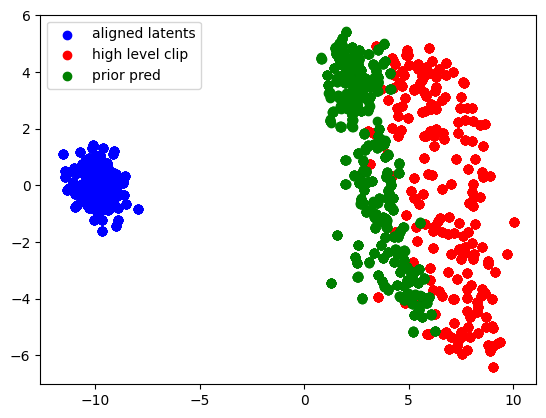

In [13]:
joint_latents = torch.cat((all_aligned_latents, all_high_clip_latents, all_prior_preds), dim=0)

pca = PCA(2)

joint_latents_lowdim = pca.fit_transform(joint_latents)
plt.scatter(joint_latents_lowdim[:n, 0], all_aligned_latents[:n, 1], c="blue", label="aligned latents")
plt.scatter(joint_latents_lowdim[n:2*n, 0], joint_latents_lowdim[n:2*n, 1], c="red", label="high level clip")
plt.scatter(joint_latents_lowdim[2*n:, 0], joint_latents_lowdim[2*n:, 1], c="green", label="prior pred")
plt.legend()

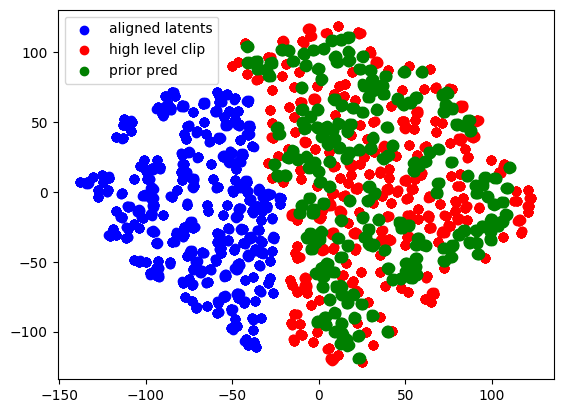

In [14]:
pca_hidden = PCA(50)
tsne = TSNE(2)

joint_latents_mid = pca_hidden.fit_transform(joint_latents)
joint_latents_low_tsne = tsne.fit_transform(joint_latents_mid)

plt.scatter(joint_latents_low_tsne[:n, 0], joint_latents_low_tsne[:n, 1], c="blue", label="aligned latents")
plt.scatter(joint_latents_low_tsne[n:2*n, 0], joint_latents_low_tsne[n:2*n, 1], c="red", label="high level clip")
plt.scatter(joint_latents_low_tsne[2*n:, 0], joint_latents_low_tsne[2*n:, 1], c="green", label="prior pred")
plt.legend()

plt.savefig("tmp_img")

In [15]:
from collections.abc import Callable

from brain_image.utils import gather_dataloader



all_data = gather_dataloader(model.val_dataloader(), batch_process_fn=lambda b: model.prepare_batch(b, stage='val'))




/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [40]:
all_preds = model.get_all_prior_preds(all_data, prior_kwargs={"generator":torch.Generator(device).manual_seed(42)})

Prior sampling: 2048it [00:08, 230.83it/s]                          


In [54]:
all_data["prior_pred"] = all_preds

INFO:root:Plotting low dim projection for val
INFO:root:Doing PCA to 50 dimensions
INFO:root:Doing TSNE to 2 dimensions


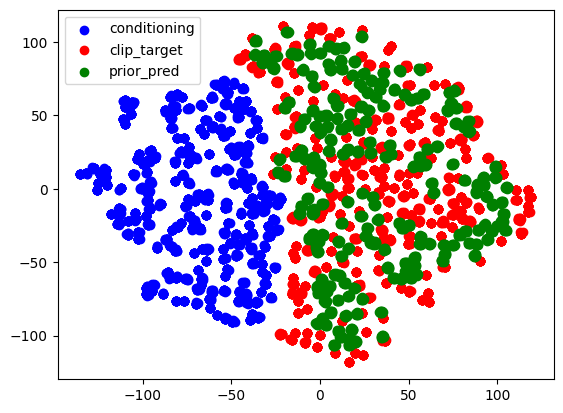

INFO:root:Finished plotting low dim projection from dimension 768 to dimension 2 in 0.000 seconds


In [63]:
model._plot_lowdim_projection(all_data, split="val", show_plot=True)

In [56]:
model.config.prior_debug_mode

True

In [66]:
import io
from PIL import Image

with io.BytesIO() as buf:
    fig = plt.gcf()
    fig.savefig(buf)
    buf.seek(0)
    img = Image.open(buf)

    img.show()

<Figure size 640x480 with 0 Axes>